# Skforecast - Model Explainability

Reproduksi dan analisis dari https://skforecast.org/0.15.1/user_guides/explainability.html

## Deskripsi

Notebook ini bertujuan untuk mereproduksi contoh explainability pada model forecasting menggunakan library Skforecast. Analisis dilakukan untuk memahami faktor-faktor yang memengaruhi hasil prediksi melalui beberapa metode interpretasi model, seperti Feature Importance, Permutation Importance, SHAP Values, dan Partial Dependence Plot (PDP). Dengan pendekatan ini, model tidak hanya menghasilkan prediksi, tetapi juga memberikan penjelasan mengenai kontribusi setiap fitur terhadap hasil yang diperoleh.

## 1. Instalasi Library

In [7]:
# Instalasi semua library yang dibutuhkan
!pip install skforecast==0.15.1 shap lightgbm matplotlib scikit-learn pandas numpy --quiet

Access is denied.


## 2. Analisis Prediksi: Tentang Apa?

Studi kasus ini menganalisis **prediksi konsumsi listrik (electricity demand)** harian, yang merupakan data **time series univariat** dengan tambahan variabel eksogen (exogenous variables).

Tujuan utamanya adalah:
- Membangun model **forecasting autoregresif** menggunakan `ForecasterRecursive` dari skforecast dengan regressor `LGBMRegressor`
- **Menjelaskan (explain)** mengapa model membuat prediksi tertentu, bukan hanya menghasilkan angka prediksi
- Memahami **fitur mana yang paling berpengaruh** terhadap prediksi menggunakan teknik interpretabilitas:
  - Feature Importance (bawaan model)
  - SHAP Values (SHapley Additive exPlanations)
  - Permutation Importance
  - Partial Dependence Plot (PDP)

## 3. Struktur Data Training

### 3.1 Konsep Transformasi Time Series → Supervised Learning

Skforecast mengubah masalah **time series** menjadi masalah **supervised machine learning** dengan cara:

$$
\text{Time Series: } y_1, y_2, y_3, \ldots, y_t
$$

Diubah menjadi tabel fitur–target:

$$
\underbrace{(y_{t-p}, y_{t-p+1}, \ldots, y_{t-1})}_{\text{INPUT (lag features)}} \xrightarrow{\text{model}} \underbrace{y_t}_{\text{OUTPUT (target)}}
$$

### 3.2 Input (Fitur / Kolom X)

| Jenis Fitur | Contoh Kolom | Deskripsi |
|---|---|---|
| **Lag features** | `lag_1`, `lag_2`, ..., `lag_24` | Nilai konsumsi listrik $p$ langkah ke belakang |
| **Exogenous variables** | `temperature`, `hour`, `dayofweek`, dll. | Variabel eksternal yang mempengaruhi konsumsi |

### 3.3 Output (Target / Kolom y)

$$
y = \text{konsumsi listrik pada waktu } t
$$

> Setiap baris pada matriks training mewakili **satu jendela waktu (window)**, di mana input adalah nilai historis dan output adalah nilai yang ingin diprediksi.

## 4. Apa Itu Lag?

**Lag** adalah nilai dari time series pada waktu-waktu sebelumnya yang digunakan sebagai fitur (input) untuk memprediksi nilai saat ini.

$$
\text{lag}_k = y_{t-k}
$$

**Contoh konkret:** Jika kita memprediksi konsumsi listrik jam 10:00, maka:

$$
\text{lag}_1 = y_{\text{jam 09:00}}, \quad \text{lag}_2 = y_{\text{jam 08:00}}, \quad \text{lag}_{24} = y_{\text{jam 10:00 hari kemarin}}
$$

**Mengapa lag penting?**
- Time series memiliki **autokorelasi** — nilai saat ini dipengaruhi nilai masa lalu
- Lag menangkap **pola periodik** (harian, mingguan, musiman)
- Semakin banyak lag yang digunakan, semakin jauh model "melihat" ke masa lalu

Dalam skforecast, kita mendefinisikan lag dengan parameter `lags=24` (misalnya), artinya model menggunakan 24 nilai historis terakhir sebagai fitur.

## 5. Import Library & Load Data

In [45]:
# Menonaktifkan warning agar output lebih bersih
import warnings
warnings.filterwarnings('ignore')

# Library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap

# Library explainability
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Model machine learning
from lightgbm import LGBMRegressor

# Library forecasting
from skforecast.recursive import ForecasterRecursive
from skforecast.datasets import fetch_dataset

# Inisialisasi SHAP
shap.initjs()

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [ ]:
# Memuat dataset konsumsi listrik
data = fetch_dataset(name='vic_electricity', raw=True)

data.head(10)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 5 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Time,Demand,Temperature,Date,Holiday
0,2011-12-31T13:00:00Z,4382.825174,21.40,2012-01-01,True
1,2011-12-31T13:30:00Z,4263.365526,21.05,2012-01-01,True
2,2011-12-31T14:00:00Z,4048.966046,20.70,2012-01-01,True
3,2011-12-31T14:30:00Z,3877.563330,20.55,2012-01-01,True
4,2011-12-31T15:00:00Z,4036.229746,20.40,2012-01-01,True
5,2011-12-31T15:30:00Z,3865.597244,20.25,2012-01-01,True
6,2011-12-31T16:00:00Z,3694.097664,20.10,2012-01-01,True
7,2011-12-31T16:30:00Z,3561.623686,19.60,2012-01-01,True
8,2011-12-31T17:00:00Z,3433.035352,19.10,2012-01-01,True
9,2011-12-31T17:30:00Z,3359.468000,18.95,2012-01-01,True


In [ ]:
# Melihat ukuran, tipe data, dan rentang waktu dataset
print(f"Shape data: {data.shape}")
print(f"Tipe data:\n{data.dtypes}")
print(f"\nRentang waktu: {data.index.min()} s/d {data.index.max()}")

Shape data: (52608, 5)
Tipe data:
Time            object
Demand         float64
Temperature    float64
Date            object
Holiday           bool
dtype: object

Rentang waktu: 0 s/d 52607


In [ ]:
# Memastikan kolom waktu tersedia dan siap digunakan
import pandas as pd

if data.index.name == 'Time':
    data = data.reset_index()

data.columns = data.columns.str.strip()

# Mengubah kolom waktu menjadi datetime dan menjadikannya index
data['Time'] = pd.to_datetime(data['Time'], utc=True)
data = data.set_index('Time')

# Resample data menjadi per jam
data = data.asfreq('30min').sort_index()
data = data.resample('h').mean(numeric_only=True)
data = data.dropna()

# Menambahkan fitur waktu (exogenous features)
data['hour']      = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month']     = data.index.month

print(f"Shape setelah preprocessing: {data.shape}")
data.head()

Shape setelah preprocessing: (26304, 6)


,Demand,Temperature,Holiday,hour,dayofweek,month
Time,,,,,,
2011-12-31 13:00:00+00:00,4323.095350,21.225,1.0,13,5,12
2011-12-31 14:00:00+00:00,3963.264688,20.625,1.0,14,5,12
2011-12-31 15:00:00+00:00,3950.913495,20.325,1.0,15,5,12
2011-12-31 16:00:00+00:00,3627.860675,19.850,1.0,16,5,12
2011-12-31 17:00:00+00:00,3396.251676,19.025,1.0,17,5,12


## 6. Visualisasi Data

Melihat pola konsumsi listrik untuk memahami karakteristik time series yang akan diprediksi.

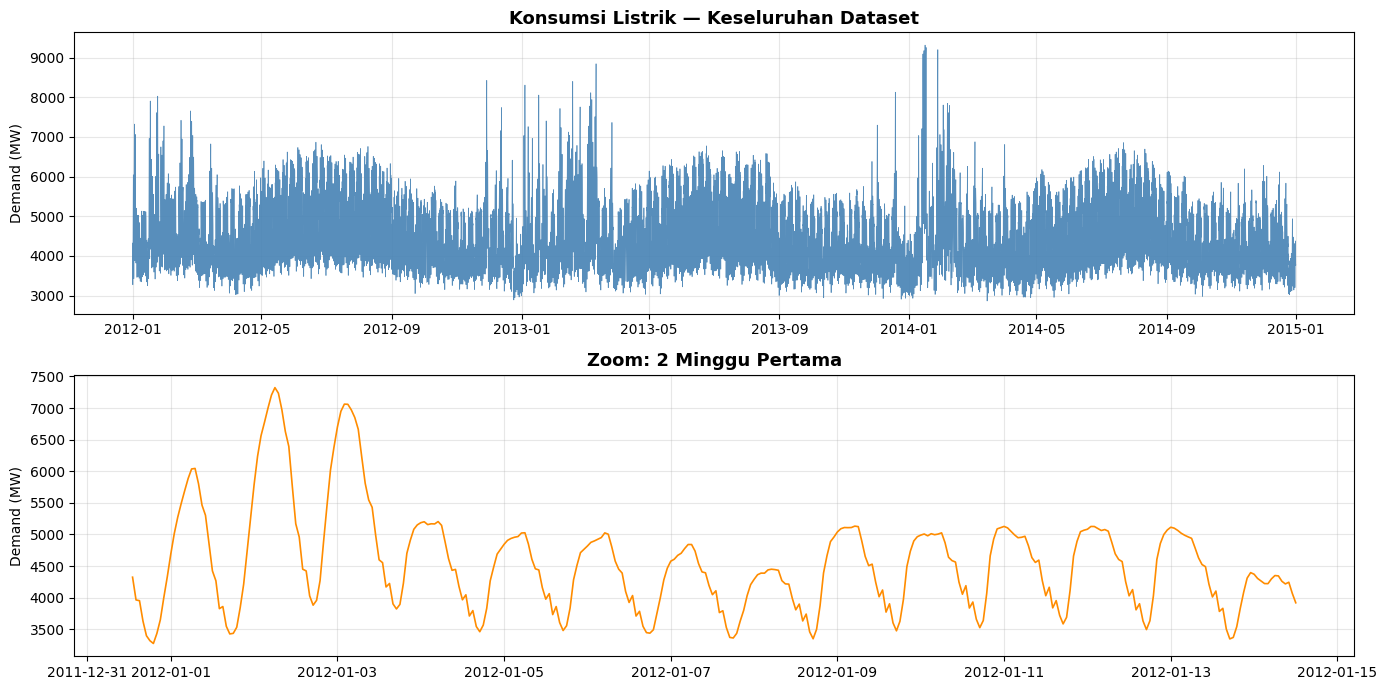

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot keseluruhan
axes[0].plot(data['Demand'], color='steelblue', linewidth=0.5, alpha=0.9)
axes[0].set_title('Konsumsi Listrik — Keseluruhan Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].grid(True, alpha=0.3)

# Plot zoom 2 minggu
zoom = data['Demand'].iloc[:24*14]
axes[1].plot(zoom, color='darkorange', linewidth=1.2)
axes[1].set_title('Zoom: 2 Minggu Pertama', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Split Data: Training & Test

In [ ]:
# Membagi dataset menjadi 90% data training dan 10% data testing
n = len(data)
cutoff = int(n * 0.9)

data_train = data.iloc[:cutoff].copy()
data_test  = data.iloc[cutoff:].copy()

print(f"Training: {data_train.index.min()} → {data_train.index.max()} ({len(data_train)} baris)")
print(f"Test    : {data_test.index.min()} → {data_test.index.max()} ({len(data_test)} baris)")

Training: 2011-12-31 13:00:00+00:00 → 2014-09-12 21:00:00+00:00 (23673 baris)
Test    : 2014-09-12 22:00:00+00:00 → 2014-12-31 12:00:00+00:00 (2631 baris)


## 8. Membangun Forecaster

### 8.1 Arsitektur Model

$$
\hat{y}_{t} = f\left(y_{t-1}, y_{t-2}, \ldots, y_{t-24},\ \text{hour}_t,\ \text{dayofweek}_t,\ \text{month}_t\right)
$$

Di mana $f$ adalah **LightGBM Regressor** (gradient boosted trees).

- `lags = 24`: gunakan 24 jam terakhir sebagai fitur lag
- Exogenous: `hour`, `dayofweek`, `month`

In [ ]:
# Membuat dan melatih model forecasting menggunakan LightGBM
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor

# Model menggunakan 24 lag (24 jam sebelumnya) sebagai input prediksi
forecaster = ForecasterRecursive(
    LGBMRegressor(
        n_estimators   = 500,
        learning_rate  = 0.05,
        max_depth      = 6,
        random_state   = 42,
        verbose        = -1
    ),
    lags = 24
)

# Menambahkan fitur waktu sebagai variabel pendukung (exogenous)
exog_cols = ['hour', 'dayofweek', 'month']

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train[exog_cols]
)

print("Forecaster berhasil dilatih!")
print(forecaster)

Forecaster berhasil dilatih!
ForecasterRecursive 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: None 
Window size: 24 
Series name: Demand 
Exogenous included: True 
Exogenous names: hour, dayofweek, month 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 13:00:00+0000', tz='UTC'), Timestamp('2014-09-12 21:00:00+0000', tz='UTC')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 500, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 42, 'reg_

### 8.2 Visualisasi Matriks Training (X_train & y_train)

Mari kita lihat **bentuk nyata** dari data training yang dibentuk oleh skforecast:

In [ ]:
# Membentuk data training (fitur dan target) untuk analisis explainability
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train[exog_cols]
)

print(f"Shape X_train (fitur): {X_train.shape}")
print(f"Shape y_train (target): {y_train.shape}")
print(f"\nKolom X_train: {list(X_train.columns)}")
print("\n5 Baris pertama X_train:")
X_train.head()

Shape X_train (fitur): (23649, 27)
Shape y_train (target): (23649,)

Kolom X_train: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'hour', 'dayofweek', 'month']

5 Baris pertama X_train:


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,hour,dayofweek,month
Time,,,,,,,,,,,,,,,,,,,,,
2012-01-01 13:00:00+00:00,4422.765949,4860.374411,5302.362170,5462.652199,5799.923228,6043.968927,6035.531240,5883.466508,5689.246067,5487.388289,...,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,3963.264688,4323.095350,13,6,1
2012-01-01 14:00:00+00:00,4265.965213,4422.765949,4860.374411,5302.362170,5462.652199,5799.923228,6043.968927,6035.531240,5883.466508,5689.246067,...,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,3963.264688,14,6,1
2012-01-01 15:00:00+00:00,3825.128319,4265.965213,4422.765949,4860.374411,5302.362170,5462.652199,5799.923228,6043.968927,6035.531240,5883.466508,...,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,15,6,1
2012-01-01 16:00:00+00:00,3858.743655,3825.128319,4265.965213,4422.765949,4860.374411,5302.362170,5462.652199,5799.923228,6043.968927,6035.531240,...,4000.933475,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,16,6,1
2012-01-01 17:00:00+00:00,3545.744810,3858.743655,3825.128319,4265.965213,4422.765949,4860.374411,5302.362170,5462.652199,5799.923228,6043.968927,...,4329.049863,4000.933475,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,17,6,1


In [ ]:
# Menampilkan beberapa nilai target (Demand) yang digunakan saat training
print("5 baris pertama y_train (target = Demand):")
y_train.head()

5 baris pertama y_train (target = Demand):


Time
2012-01-01 13:00:00+00:00    4265.965213
2012-01-01 14:00:00+00:00    3825.128319
2012-01-01 15:00:00+00:00    3858.743655
2012-01-01 16:00:00+00:00    3545.744810
2012-01-01 17:00:00+00:00    3425.274352
Freq: h, Name: y, dtype: float64

## 9. Proses Analisis Explainability

### 9.1 Feature Importance (Bawaan Model)

LightGBM secara internal menghitung **seberapa sering** dan **seberapa besar** setiap fitur berkontribusi dalam pembentukan pohon keputusan.

$$
\text{Importance}(f_j) = \sum_{\text{trees}} \sum_{\text{splits}} \mathbb{1}[\text{fitur } f_j \text{ digunakan}] \times \Delta \text{impurity}
$$

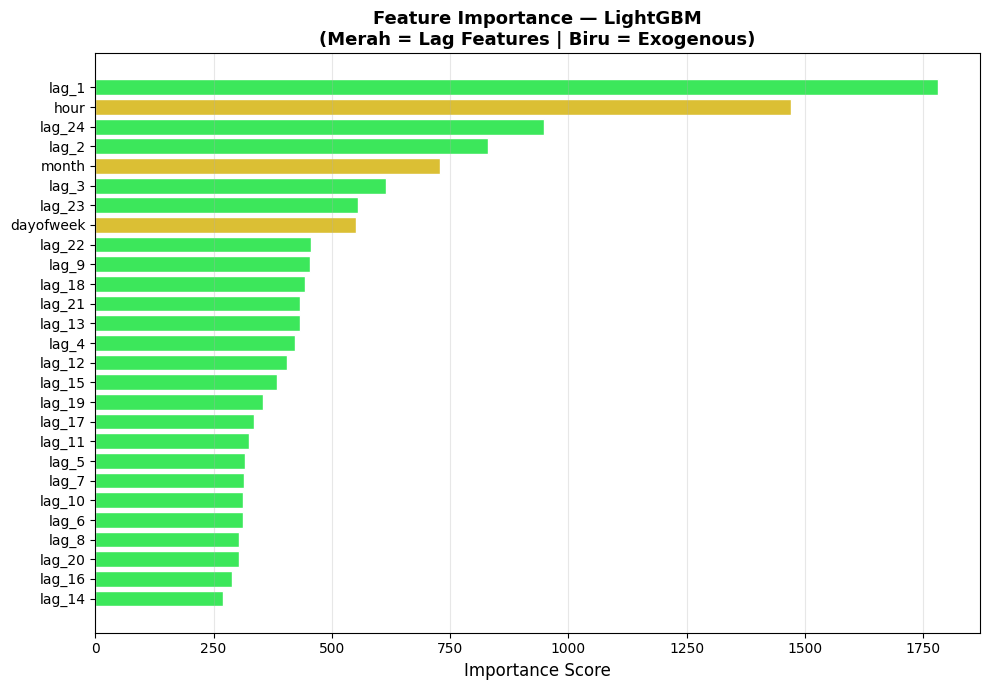


Top 10 fitur terpenting:
  feature  importance
    lag_1        1781
     hour        1470
   lag_24         948
    lag_2         830
    month         728
    lag_3         614
   lag_23         556
dayofweek         552
   lag_22         456
    lag_9         454


In [ ]:
# Menghitung dan mengurutkan feature importance dari model
importance_df = forecaster.get_feature_importances()
importance_df = importance_df.sort_values('importance', ascending=False)

# Membuat visualisasi feature importance
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#3ce75b" if 'lag' in f else "#dbbf34" for f in importance_df['feature']]

ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(
    'Feature Importance — LightGBM\n(Merah = Lag Features | Biru = Exogenous)',
    fontsize=13,
    fontweight='bold'
)

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Menampilkan 10 fitur yang paling berpengaruh terhadap prediksi
print("\nTop 10 fitur terpenting:")
print(importance_df.head(10).to_string(index=False))

### 9.2 SHAP Values (SHapley Additive exPlanations)

SHAP berasal dari **game theory** (Shapley values). Ide dasarnya: setiap fitur adalah "pemain" dalam permainan kooperatif, dan SHAP mengukur kontribusi adil setiap pemain terhadap prediksi.

$$
\hat{y}_i = \phi_0 + \sum_{j=1}^{p} \phi_{ij}
$$

Di mana:
- $\hat{y}_i$ = prediksi untuk sampel ke-$i$
- $\phi_0$ = nilai dasar (rata-rata prediksi model)
- $\phi_{ij}$ = kontribusi SHAP fitur ke-$j$ untuk sampel ke-$i$

**Properti penting:** Jumlah semua SHAP values selalu sama dengan selisih prediksi dengan rata-rata:
$$
\hat{y}_i - \mathbb{E}[\hat{y}] = \sum_{j=1}^{p} \phi_{ij}
$$

In [ ]:
# Mengambil model LightGBM dari forecaster untuk analisis SHAP
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]

# Membuat SHAP TreeExplainer dan menghitung nilai SHAP
explainer = shap.TreeExplainer(internal_model)

# Menggunakan sebagian data training agar proses lebih cepat
X_sample = X_train.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Menampilkan ukuran hasil SHAP values
print(f"Shape SHAP values: {shap_values.shape}")
print(f"(baris = sampel, kolom = fitur)")

Shape SHAP values: (1000, 27)
(baris = sampel, kolom = fitur)


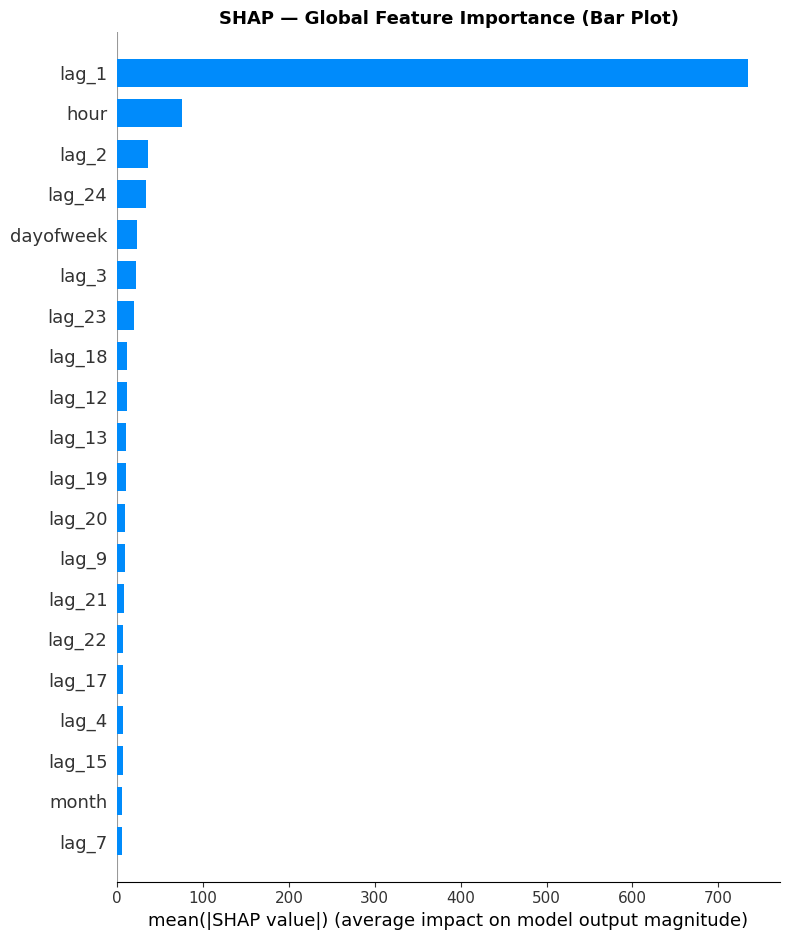

In [ ]:
# Membuat visualisasi SHAP untuk melihat pengaruh fitur secara global
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)

plt.title(
    'SHAP — Global Feature Importance (Bar Plot)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

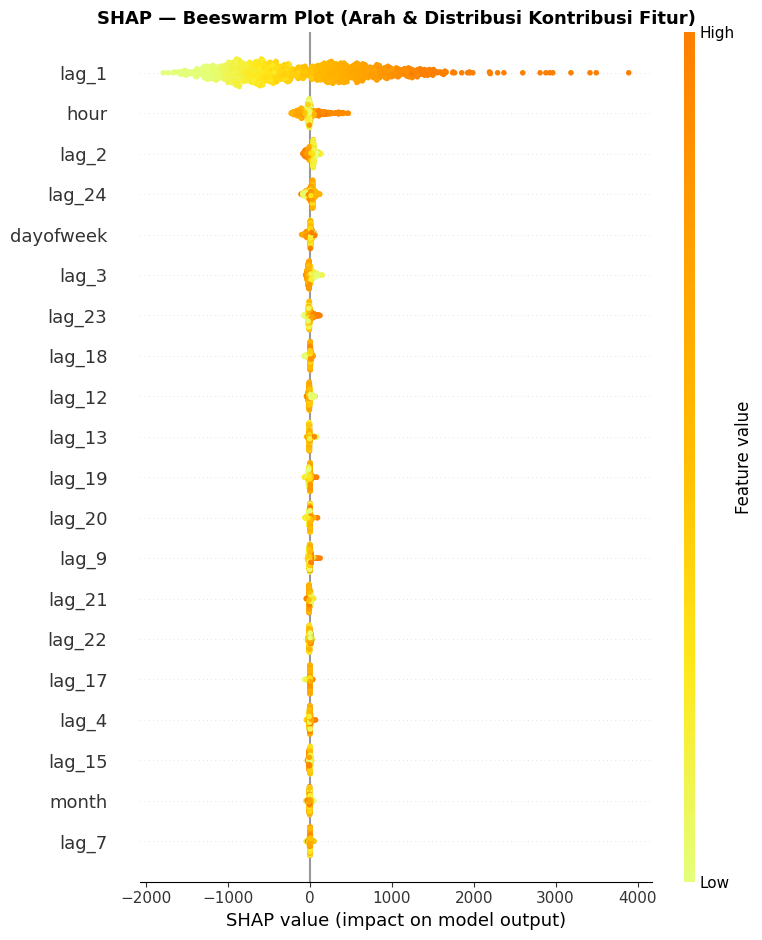

In [ ]:
# Membuat visualisasi SHAP Beeswarm untuk melihat arah dan sebaran pengaruh fitur
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_sample,
    cmap='Wistia',
    show=False
)

plt.title(
    'SHAP — Beeswarm Plot (Arah & Distribusi Kontribusi Fitur)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Cara membaca Beeswarm Plot:**
- **Sumbu X** = nilai SHAP (positif = mendorong prediksi naik, negatif = mendorong turun)
- **Warna merah** = nilai fitur tinggi, **biru** = nilai fitur rendah
- **Titik tersebar** = distribusi kontribusi di seluruh sampel

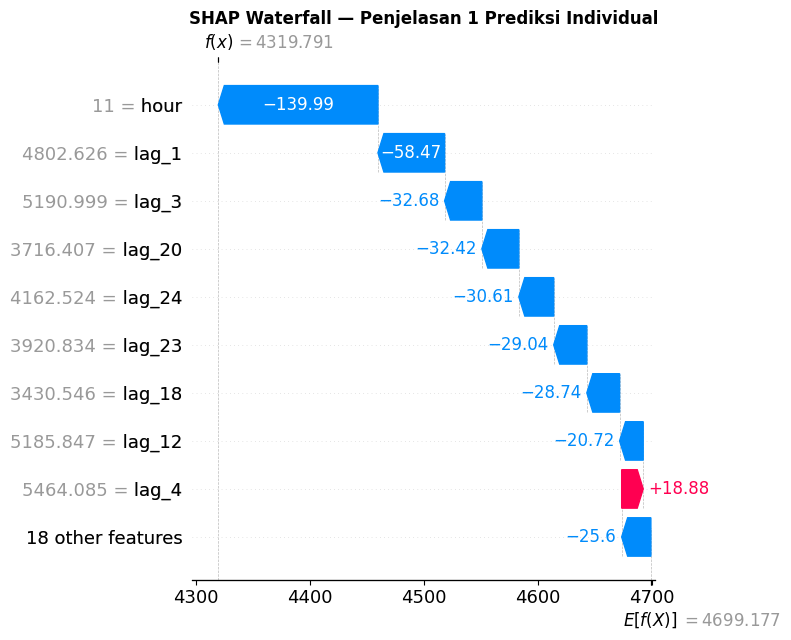

In [ ]:
# SHAP Waterfall Plot — Penjelasan 1 Prediksi Spesifik

idx = 0  # sampel ke-0
shap_explanation = shap.Explanation(
    values       = shap_values[idx],
    base_values  = explainer.expected_value,
    data         = X_sample.iloc[idx].values,
    feature_names= X_sample.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False)
plt.title('SHAP Waterfall — Penjelasan 1 Prediksi Individual', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Cara membaca Waterfall Plot:**
- **E[f(x)]** = rata-rata semua prediksi model (baseline)
- **f(x)** = prediksi akhir untuk sampel ini
- Setiap bar menunjukkan seberapa besar **satu fitur** mengubah prediksi dari baseline ke hasil akhir

### 9.3 Permutation Importance

Permutation importance mengukur **seberapa besar performa model menurun** ketika nilai sebuah fitur **diacak secara acak** (sehingga memutus hubungannya dengan target).

$$
\text{PI}(f_j) = \overline{\text{score}_{\text{baseline}}} - \overline{\text{score}_{\text{after permuting } f_j}}
$$

Semakin besar penurunan performa → semakin penting fitur tersebut.

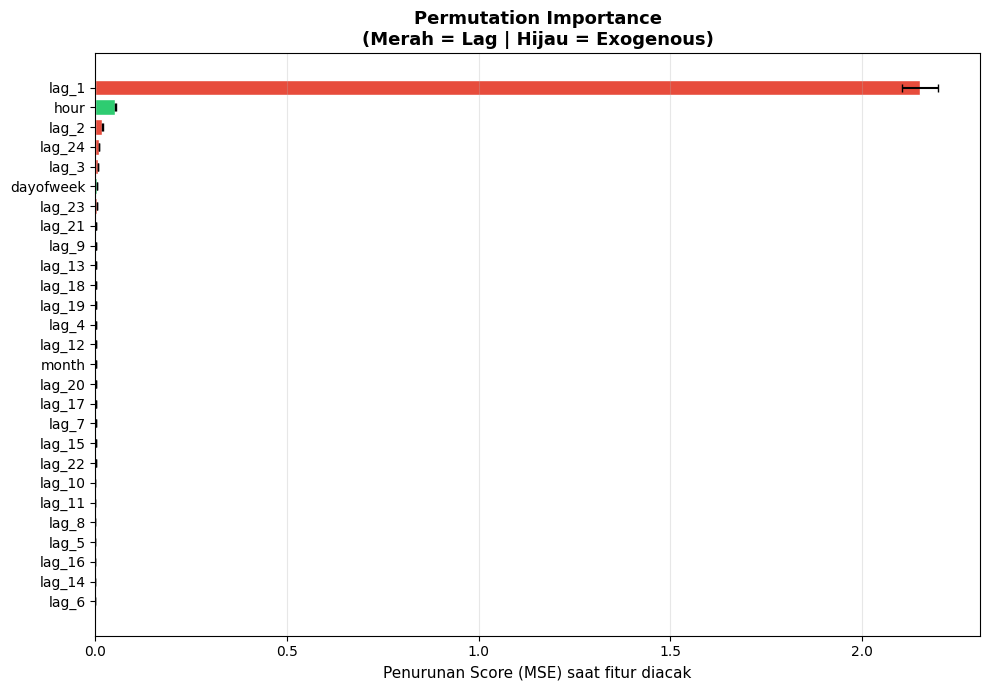

In [47]:
# Mengambil model LightGBM dari forecaster
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]


# Mengambil sampel data training agar proses lebih cepat
sample_size = min(1000, len(X_train))
X_sample_perm = X_train.sample(n=sample_size, random_state=42)
y_sample_perm = y_train.loc[X_sample_perm.index]


# Menghitung Permutation Importance
result = permutation_importance(
    estimator    = internal_model,
    X            = X_sample_perm,
    y            = y_sample_perm,
    n_repeats    = 5,
    random_state = 42,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'feature'           : X_sample_perm.columns,
    'importance_mean'   : result.importances_mean,
    'importance_std'    : result.importances_std
}).sort_values('importance_mean', ascending=False)

# Membuat visualisasi hasil Permutation Importance
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if 'lag' in f else '#2ecc71' for f in perm_df['feature']]

ax.barh(
    perm_df['feature'],
    perm_df['importance_mean'],
    xerr  = perm_df['importance_std'],
    color = colors,
    edgecolor='white',
    capsize=3
)

ax.set_xlabel('Penurunan Score (MSE) saat fitur diacak', fontsize=11)
ax.set_title('Permutation Importance\n(Merah = Lag | Hijau = Exogenous)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.4 Partial Dependence Plot (PDP)

PDP menunjukkan **hubungan rata-rata** antara satu fitur dengan output prediksi, dengan mengisolasi efek fitur lain (dianggap konstan).

$$
\hat{f}_{x_j}(x_j) = \mathbb{E}_{X_{\setminus j}}\left[\hat{f}(x_j, X_{\setminus j})\right] = \frac{1}{n}\sum_{i=1}^{n} \hat{f}(x_j, x_{\setminus j}^{(i)})
$$

Di mana $X_{\setminus j}$ adalah semua fitur selain $x_j$.

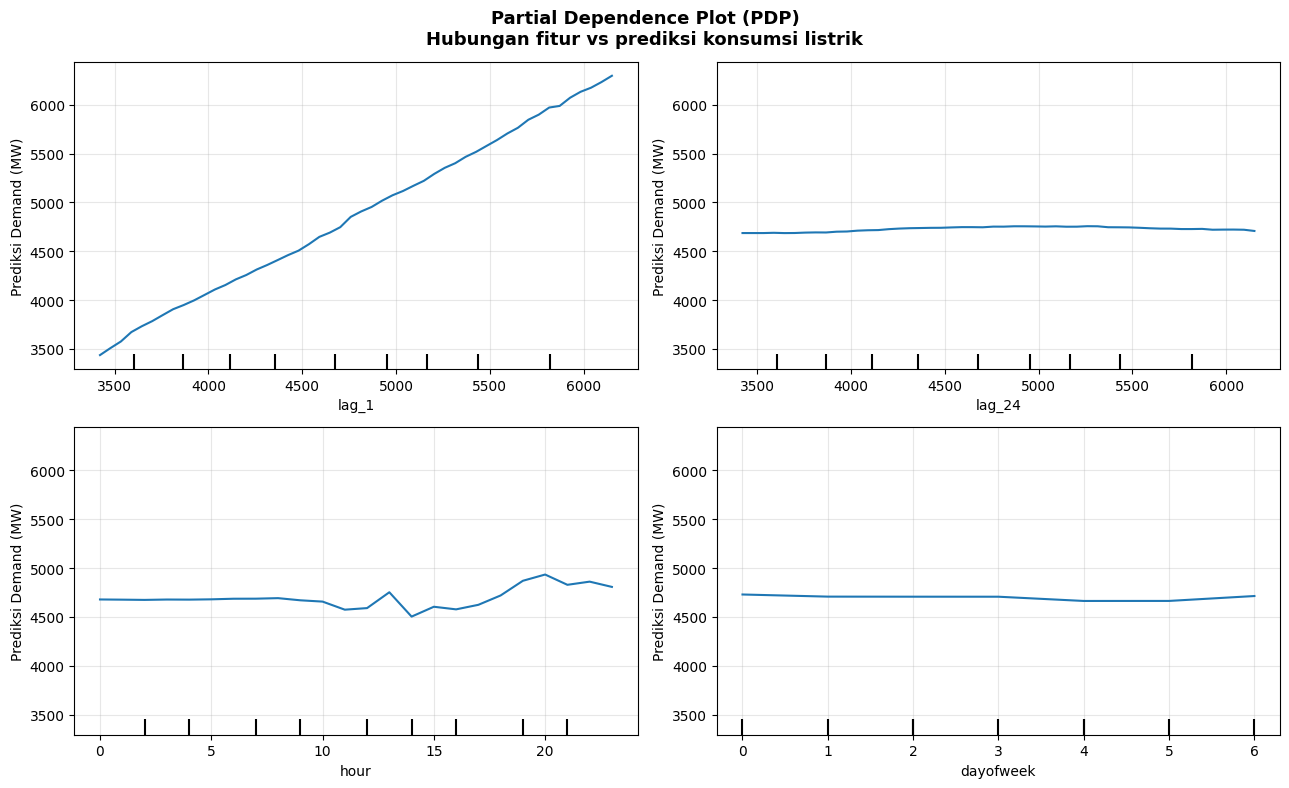

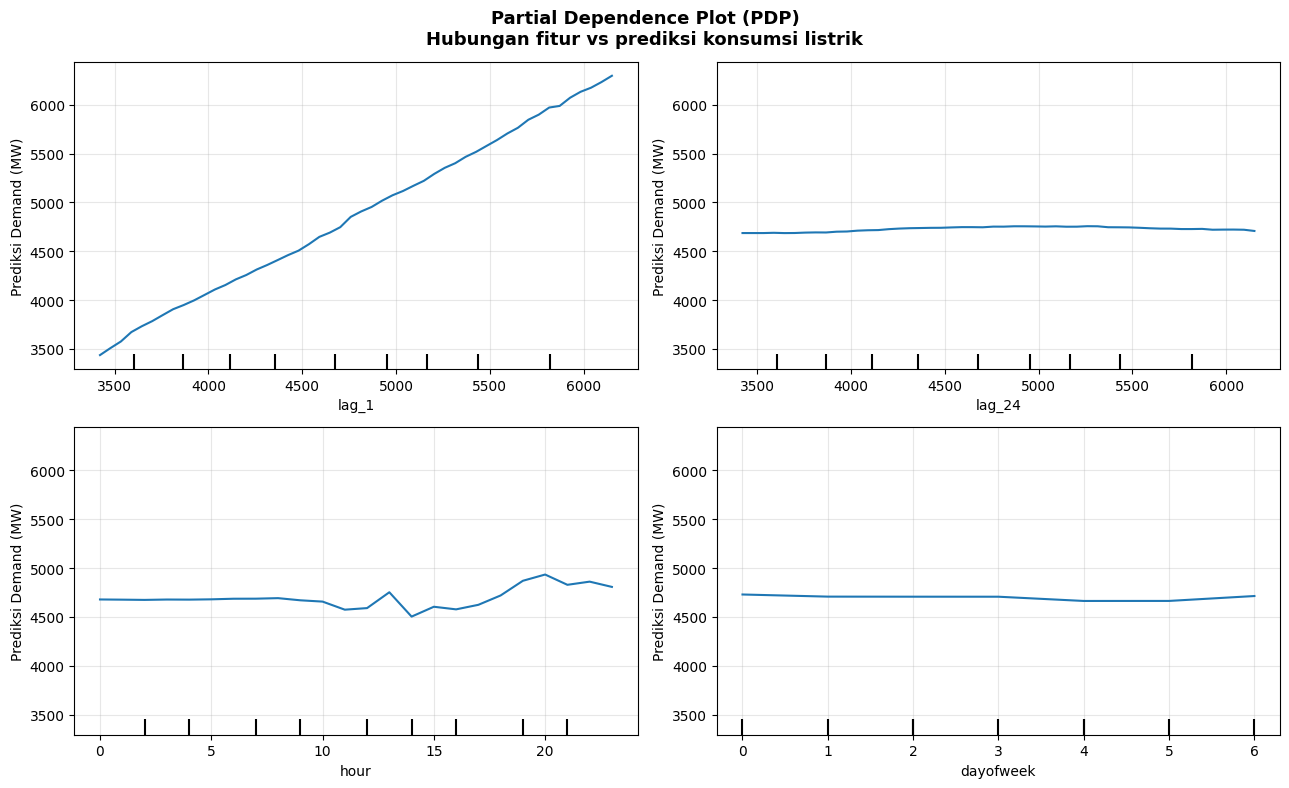

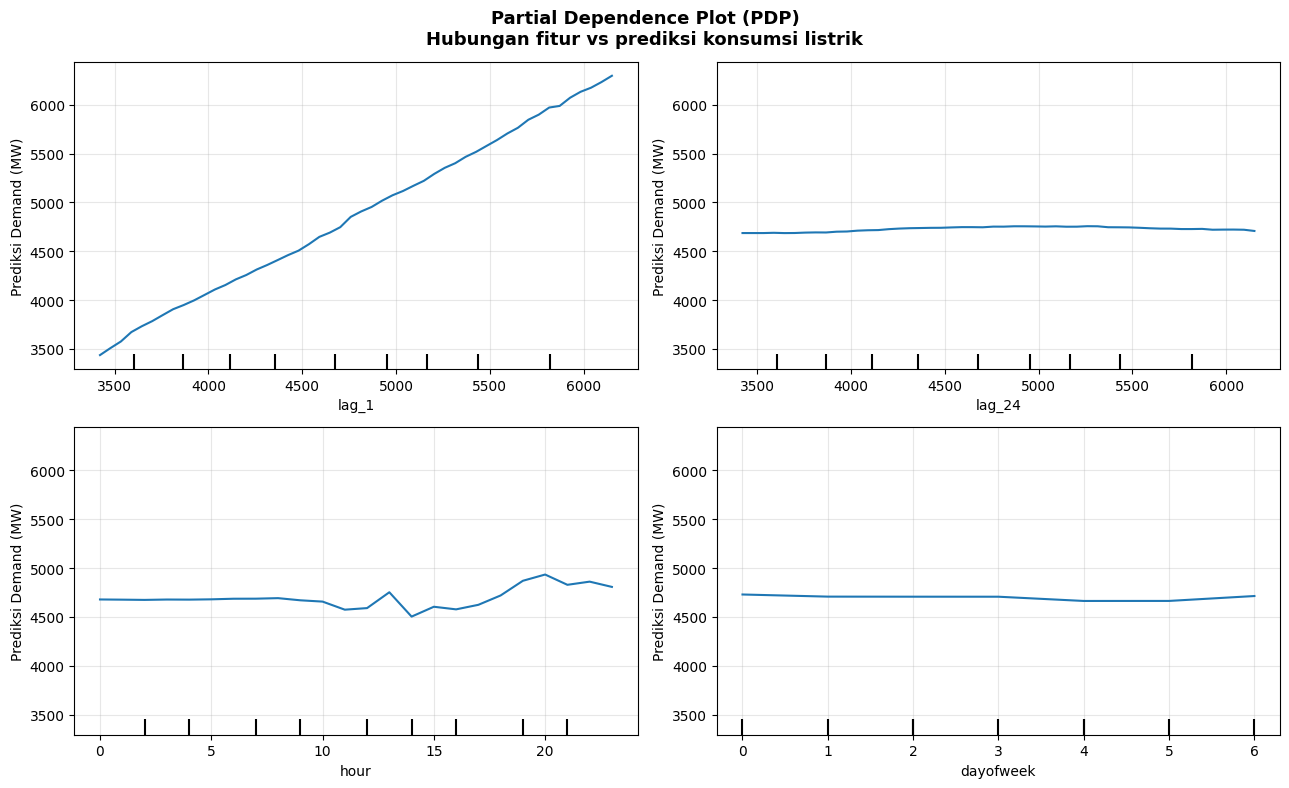

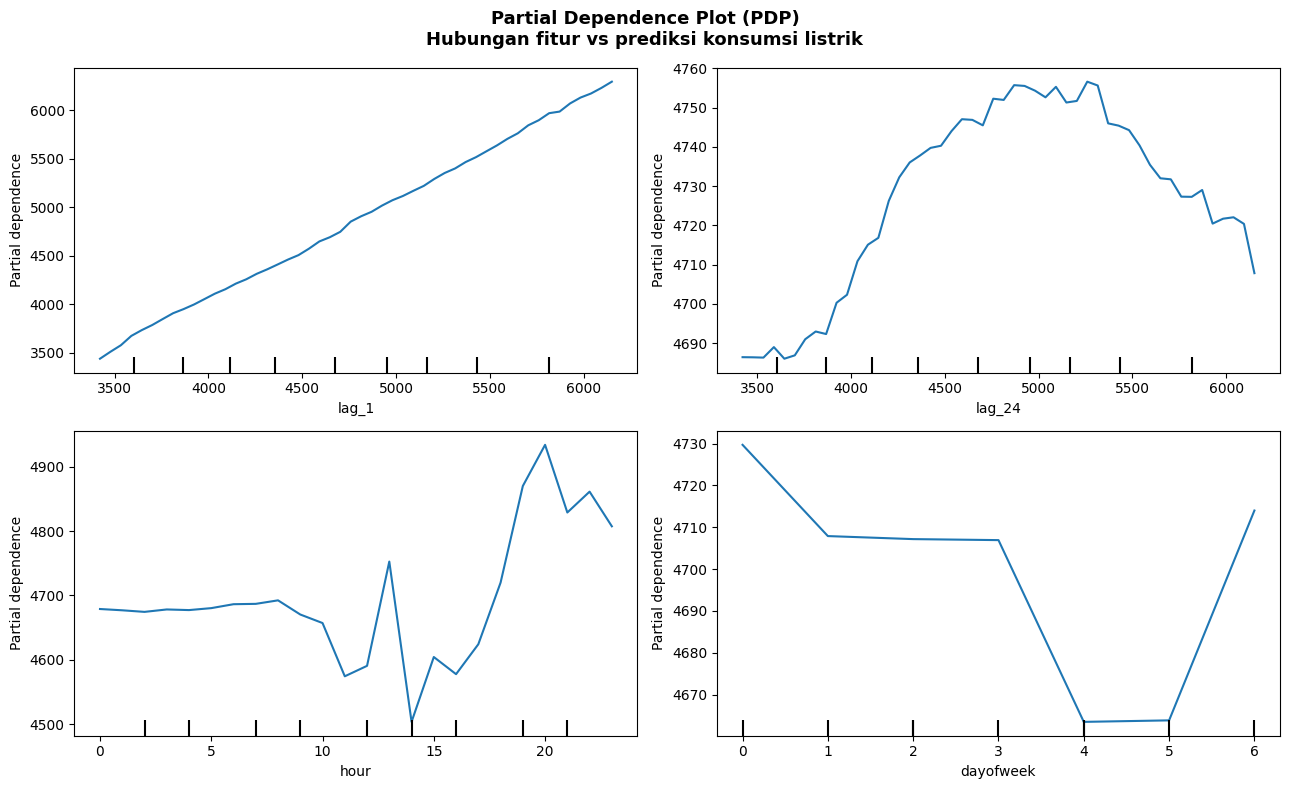

In [54]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Mengambil model LightGBM dari forecaster
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]

# Menyiapkan data dan memilih fitur yang akan dianalisis
X_train_float = X_train.astype('float64')
top_features = ['lag_1', 'lag_24', 'hour', 'dayofweek']

# Membuat visualisasi Partial Dependence Plot (PDP)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.ravel()

for i, feature in enumerate(top_features):
    PartialDependenceDisplay.from_estimator(
        estimator    = internal_model,
        X            = X_train_float,
        features     = [feature],
        feature_names=X_train_float.columns.tolist(),
        ax           = axes_flat[i],
        grid_resolution=50
    )

# Menambahkan judul dan mempercantik tampilan grafik
fig.suptitle(
    'Partial Dependence Plot (PDP)\nHubungan fitur vs prediksi konsumsi listrik',
    fontsize=13,
    fontweight='bold',
    y=0.98
)

for ax in axes_flat:
    ax.set_ylabel('Prediksi Demand (MW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Prediksi & Evaluasi Model

In [ ]:
# Melakukan prediksi pada seluruh data testing
predictions = forecaster.predict(
    steps = len(data_test),
    exog  = data_test[exog_cols]
)

# Menghitung metrik evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = data_test['Demand'].values
y_pred = predictions.values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Menampilkan hasil evaluasi performa model
print(f"{'='*40}")
print(f"  Evaluasi Model pada Data Test")
print(f"{'='*40}")
print(f"  MAE  : {mae:,.2f} MW")
print(f"  RMSE : {rmse:,.2f} MW")
print(f"  MAPE : {mape:.2f}%")
print(f"{'='*40}")

  Evaluasi Model pada Data Test
  MAE  : 236.85 MW
  RMSE : 340.61 MW
  MAPE : 5.37%


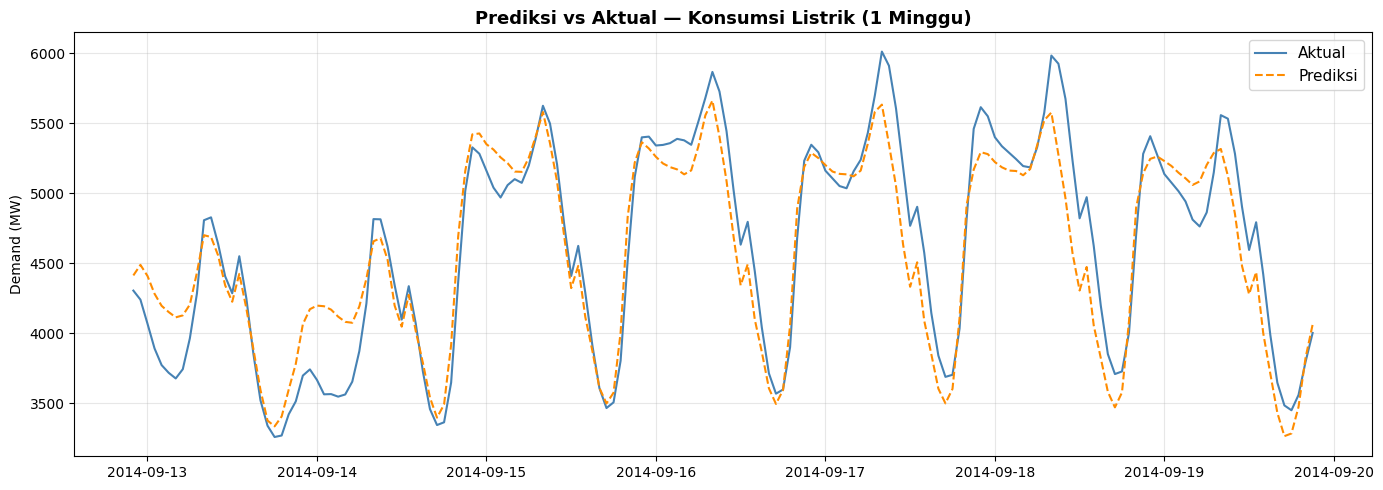

In [44]:
# Menampilkan perbandingan data aktual dan hasil prediksi selama 1 minggu
n_plot = 24 * 7  # 1 minggu

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data_test['Demand'].iloc[:n_plot], 
        label='Aktual', color='steelblue', linewidth=1.5)
ax.plot(predictions.iloc[:n_plot], 
        label='Prediksi', color='darkorange', linewidth=1.5, linestyle='--')

# Menambahkan judul, label, dan legenda grafik
ax.set_title('Prediksi vs Aktual — Konsumsi Listrik (1 Minggu)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Ringkasan Proses Analisis

### 11.1 Alur Lengkap Analisis

```text
Data Konsumsi Listrik (Demand)
            │
            ▼
┌────────────────────────────────────────────┐
│ Persiapan dan Pembersihan Data             │
│ - Memastikan tidak ada data kosong         │
│ - Mengatur format waktu (datetime)         │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Feature Engineering                        │
│ Membuat fitur waktu:                       │
│ - hour (jam)                               │
│ - dayofweek (hari)                         │
│ - month (bulan)                            │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Transformasi Time Series                   │
│ menjadi Supervised Learning                │
│                                            │
│ Input (X):                                 │
│ - lag_1 sampai lag_24                      │
│ - hour                                     │
│ - dayofweek                                │
│ - month                                    │
│                                            │
│ Output (y):                                │
│ - Demand pada waktu t                      │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Pembagian Dataset                          │
│ - Data Training                            │
│ - Data Testing                             │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Training Model                             │
│ ForecasterRecursive + LightGBM Regressor   │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Prediksi Data Testing                      │
│ Menghasilkan nilai Demand prediksi         │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Evaluasi Model                             │
│ - MAE                                      │
│ - RMSE                                     │
│ - MAPE                                     │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Analisis Explainability                    │
├────────────────────────────────────────────┤
│ Feature Importance                         │
│ → Mengetahui fitur paling penting          │
│                                            │
│ SHAP Values                                │
│ → Menjelaskan kontribusi tiap fitur        │
│                                            │
│ Permutation Importance                     │
│ → Mengukur dampak fitur terhadap model     │
│                                            │
│ Partial Dependence Plot (PDP)              │
│ → Melihat hubungan fitur dengan prediksi   │
└────────────────────────────────────────────┘
            │
            ▼
┌────────────────────────────────────────────┐
│ Interpretasi dan Kesimpulan                │
│ Menentukan faktor yang paling berpengaruh  │
│ terhadap konsumsi listrik                  │
└────────────────────────────────────────────┘
```

### 11.2 Kesimpulan Hasil Analisis

| Metode | Hasil Utama |
|----------|----------|
| **Feature Importance** | Fitur **lag_1** dan **lag_24** menjadi fitur yang paling berpengaruh dalam proses prediksi. Hal ini menunjukkan bahwa konsumsi listrik pada 1 jam dan 24 jam sebelumnya sangat membantu model dalam memprediksi nilai berikutnya. |
| **SHAP Values** | Fitur **hour (jam)** memiliki kontribusi besar terhadap hasil prediksi. Jam tertentu dapat meningkatkan atau menurunkan prediksi konsumsi listrik sesuai pola penggunaan harian. |
| **Permutation Importance** | Ketika fitur **lag_1** dan **hour** diacak, performa model mengalami penurunan yang cukup besar. Hal ini menunjukkan bahwa kedua fitur tersebut sangat penting bagi model. |
| **Partial Dependence Plot (PDP)** | Grafik menunjukkan adanya pola konsumsi listrik yang berubah sesuai waktu. Konsumsi cenderung meningkat pada jam-jam aktivitas tinggi dan menurun pada jam-jam tertentu. |

### 11.3 Mengapa Explainability Penting?

1. **Memahami cara kerja model**, sehingga hasil prediksi tidak hanya dianggap sebagai angka keluaran tanpa penjelasan.
2. **Meningkatkan kepercayaan pengguna**, karena faktor yang memengaruhi prediksi dapat diketahui dengan jelas.
3. **Membantu proses debugging**, terutama ketika model menghasilkan prediksi yang tidak sesuai dengan kondisi sebenarnya.
4. **Memudahkan pengembangan model**, karena fitur yang kurang penting dapat dihilangkan sehingga model menjadi lebih efisien.
5. **Mendukung transparansi dan audit model**, terutama pada sektor yang membutuhkan keputusan yang dapat dipertanggungjawabkan.

### 11.4 Kesimpulan

Berdasarkan hasil reproduksi notebook *Skforecast Model Explainability*, model forecasting berhasil memanfaatkan data historis konsumsi listrik untuk memprediksi nilai konsumsi pada waktu berikutnya. Fitur berbasis waktu seperti **lag_1**, **lag_24**, dan **hour** terbukti menjadi faktor yang paling berpengaruh terhadap hasil prediksi.

Penerapan metode explainability seperti **Feature Importance**, **SHAP Values**, **Permutation Importance**, dan **Partial Dependence Plot (PDP)** memberikan pemahaman yang lebih mendalam mengenai proses pengambilan keputusan model. Dengan demikian, model tidak hanya menghasilkan prediksi yang akurat, tetapi juga mampu menjelaskan alasan di balik prediksi yang dihasilkan.